In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os

In [2]:
# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
base_dir = './UAV_Classification_Dataset/dataset/MFCC'

# taking a subset of data to start

class_names = [
     'DJI_Phantom2',
     'UDI_U46',
     'Syma_X20',
     'Hasakee_Q11',
     'Hover_X1',
     'PhenoBee',
     'DJI_Matrice200_v2',
     'DJI_Mini3_pro',
     'Yuneec_Typhoon_H_Plus',
     'DJI_Phantom4',
     'DJI_Tello_TT',
     'DJI_FPV',
     'Syma_X26',
     'DJI_Tello',
     'DJI_Matrice600p',
     'DJI_Neo',
     'Holystone_HS210',
     'DJI_Avata',
     'DJI_Mavic2s',
     'DJI_Mavic_Air2',
     'Autel_Evo_II',
     'DJI_Mini3',
     'DJI_Mavic_Mini1',
     'DJI_Mavic_Mini2',
     'Syma_X8SW',
     'Syma_X5UW',
     'DJI_Mavic2pro',
     'DJI_Matrice200',
     'Syma_X20P',
     'David_Tricopter',
     'Swellpro_Splash3_plus',
     'Syma_X5SW'
]
os.listdir(base_dir)

['DJI_Mavic2pro',
 'DJI_Tello_TT',
 'Syma_X26',
 'Syma_X8SW',
 'DJI_Matrice200_v2',
 'Holystone_HS210',
 'Swellpro_Splash3_plus',
 'David_Tricopter',
 'PhenoBee',
 'DJI_Matrice600p',
 'Hasakee_Q11',
 'DJI_Neo',
 'DJI_Mini3_pro',
 'Syma_X20P',
 'Yuneec_Typhoon_H_Plus',
 'DJI_Matrice200',
 'DJI_FPV',
 'DJI_Mini3',
 'Autel_Evo_II',
 'UDI_U46',
 'DJI_Mavic_Mini2',
 'DJI_Mavic_Air2',
 'Hover_X1',
 'DJI_Mavic_Mini1',
 'Syma_X5SW',
 'DJI_Phantom2',
 'Syma_X5UW',
 'Syma_X20',
 'DJI_Mavic2s',
 'DJI_Tello',
 'DJI_Avata',
 'DJI_Phantom4']

In [4]:
# ------------------------------------
# PREP DATA
# ------------------------------------

In [5]:
base_name = 'cases_resized'
width = 80

In [6]:
# getting number of instances per class
for class_name in class_names:
    class_folder = os.path.join(base_dir, class_name);
    files = [f for f in os.listdir(class_folder)]
    print(class_name + ": " + str(len(files)) + " instances in class")

DJI_Phantom2: 100 instances in class
UDI_U46: 100 instances in class
Syma_X20: 100 instances in class
Hasakee_Q11: 100 instances in class
Hover_X1: 100 instances in class
PhenoBee: 100 instances in class
DJI_Matrice200_v2: 100 instances in class
DJI_Mini3_pro: 100 instances in class
Yuneec_Typhoon_H_Plus: 100 instances in class
DJI_Phantom4: 100 instances in class
DJI_Tello_TT: 100 instances in class
DJI_FPV: 100 instances in class
Syma_X26: 100 instances in class
DJI_Tello: 100 instances in class
DJI_Matrice600p: 100 instances in class
DJI_Neo: 100 instances in class
Holystone_HS210: 100 instances in class
DJI_Avata: 100 instances in class
DJI_Mavic2s: 100 instances in class
DJI_Mavic_Air2: 100 instances in class
Autel_Evo_II: 100 instances in class
DJI_Mini3: 100 instances in class
DJI_Mavic_Mini1: 100 instances in class
DJI_Mavic_Mini2: 100 instances in class
Syma_X8SW: 100 instances in class
Syma_X5UW: 100 instances in class
DJI_Mavic2pro: 100 instances in class
DJI_Matrice200: 100

In [57]:
# RESIZE IMAGES
import joblib
from skimage.io import imread
# from skimage.transform import resize
# *********** USE DIFFERENT LIBRARY FOR SPEED ***********
# !pip install opencv-python
import cv2
import numpy as np
import os

def resize_all(src, pklname, include, width=150, height=None):
    """
    load images from path, resize them and write them as arrays to a dictionary,
    together with labels and metadata. The dictionary is written to a pickle file
    named '{pklname}_{width}x{height}px.pkl'.

    Parameter
    ---------
    src: str
        path to data
    pklname: str
        path to output file
    width: int
        target width of the image in pixels
    include: set[str]
        set containing str
    """
    height = height if height is not None else width

    data = dict()
    data['description'] = 'resized ({0}x{1})MFCC extractions in rgb'.format(int(width), int(height))
    data['label'] = []
    data['filename'] = []
    data['data'] = []

    pklname = f"{pklname}_{width}x{height}px.pkl"

    # read all images in PATH, resize and write to DESTINATION_PATH
    for subdir in os.listdir(src):
        if subdir in include:
            print(subdir)
            current_path = os.path.join(src, subdir)

            for file in os.listdir(current_path):
                if file[-3:] in {'jpg', 'png'}:
                    im = cv2.imread(os.path.join(current_path, file))
                    im = cv2.resize(im, (width, height), interpolation=cv2.INTER_AREA) #[:,:,::-1]

                    # !!!!!!!!! extract base name to avoid labeling error !!!!!!!!!!
                    filename = os.path.basename(subdir)
                    data['label'].append(filename)
                    # data['label'].append(subdir[:-4])
                    data['filename'].append(file)
                    data['data'].append(im)

        joblib.dump(data, pklname)

In [58]:
# RESIZE IMAGES
!pip install imageio[pyav]

data_path = './UAV_Classification_Dataset/dataset/MFCC'
base_name = 'cases_resized'
width = 128
##### VERY SMALL VERSION ######
include = {
     'DJI_Phantom2',
     'UDI_U46',
     'Syma_X20',
     'Hasakee_Q11',
     'Hover_X1',
     'PhenoBee',
     'DJI_Matrice200_v2',
     'DJI_Mini3_pro',
     'Yuneec_Typhoon_H_Plus',
     'DJI_Phantom4',
     'DJI_Tello_TT',
     'DJI_FPV',
     'Syma_X26',
     'DJI_Tello',
     'DJI_Matrice600p',
     'DJI_Neo',
     'Holystone_HS210',
     'DJI_Avata',
     'DJI_Mavic2s',
     'DJI_Mavic_Air2',
     'Autel_Ev6o_II',
     'DJI_Mini3',
     'DJI_Mavic_Mini1',
     'DJI_Mavic_Mini2',
     'Syma_X8SW',
     'Syma_X5UW',
     'DJI_Mavic2pro',
     'DJI_Matrice200',
     'Syma_X20P',
     'David_Tricopter',
     'Swellpro_Splash3_plus',
     'Syma_X5SW'
 }
resize_all(src=data_path, pklname=base_name, width=width, include=include)

DJI_Mavic2pro
DJI_Tello_TT
Syma_X26
Syma_X8SW
DJI_Matrice200_v2
Holystone_HS210
Swellpro_Splash3_plus
David_Tricopter
PhenoBee
DJI_Matrice600p
Hasakee_Q11
DJI_Neo
DJI_Mini3_pro
Syma_X20P
Yuneec_Typhoon_H_Plus
DJI_Matrice200
DJI_FPV
DJI_Mini3
UDI_U46
DJI_Mavic_Mini2
DJI_Mavic_Air2
Hover_X1
DJI_Mavic_Mini1
Syma_X5SW
DJI_Phantom2
Syma_X5UW
Syma_X20
DJI_Mavic2s
DJI_Tello
DJI_Avata
DJI_Phantom4


In [60]:
# load the data from disk and print a summary
import joblib
from collections import Counter
 
data = joblib.load(f'{base_name}_{width}x{width}px.pkl')
 
print('number of samples: ', len(data['data']))
print('keys: ', list(data.keys()))
print('description: ', data['description'])
print('image shape: ', data['data'][0].shape)
print('labels:', np.unique(data['label']))
 
Counter(data['label'])

number of samples:  3100
keys:  ['description', 'label', 'filename', 'data']
description:  resized (128x128)MFCC extractions in rgb
image shape:  (128, 128, 3)
labels: ['DJI_Avata' 'DJI_FPV' 'DJI_Matrice200' 'DJI_Matrice200_v2'
 'DJI_Matrice600p' 'DJI_Mavic2pro' 'DJI_Mavic2s' 'DJI_Mavic_Air2'
 'DJI_Mavic_Mini1' 'DJI_Mavic_Mini2' 'DJI_Mini3' 'DJI_Mini3_pro' 'DJI_Neo'
 'DJI_Phantom2' 'DJI_Phantom4' 'DJI_Tello' 'DJI_Tello_TT'
 'David_Tricopter' 'Hasakee_Q11' 'Holystone_HS210' 'Hover_X1' 'PhenoBee'
 'Swellpro_Splash3_plus' 'Syma_X20' 'Syma_X20P' 'Syma_X26' 'Syma_X5SW'
 'Syma_X5UW' 'Syma_X8SW' 'UDI_U46' 'Yuneec_Typhoon_H_Plus']


Counter({'DJI_Mavic2pro': 100,
         'DJI_Tello_TT': 100,
         'Syma_X26': 100,
         'Syma_X8SW': 100,
         'DJI_Matrice200_v2': 100,
         'Holystone_HS210': 100,
         'Swellpro_Splash3_plus': 100,
         'David_Tricopter': 100,
         'PhenoBee': 100,
         'DJI_Matrice600p': 100,
         'Hasakee_Q11': 100,
         'DJI_Neo': 100,
         'DJI_Mini3_pro': 100,
         'Syma_X20P': 100,
         'Yuneec_Typhoon_H_Plus': 100,
         'DJI_Matrice200': 100,
         'DJI_FPV': 100,
         'DJI_Mini3': 100,
         'UDI_U46': 100,
         'DJI_Mavic_Mini2': 100,
         'DJI_Mavic_Air2': 100,
         'Hover_X1': 100,
         'DJI_Mavic_Mini1': 100,
         'Syma_X5SW': 100,
         'DJI_Phantom2': 100,
         'Syma_X5UW': 100,
         'Syma_X20': 100,
         'DJI_Mavic2s': 100,
         'DJI_Tello': 100,
         'DJI_Avata': 100,
         'DJI_Phantom4': 100})

In [61]:
# save the dictionary of resize images to a npy file
np.save("drone_mfccs_128.npy", data)

# TO LOAD THIS:
# read_dict = np.load("drone_mfccs_128.npy", allow_pickle='TRUE').item()
# print(read_dict['DJI_Avata'] # displays this class data

In [62]:
# name input data X and result (labels) y
X = np.array(data['data'])
y = np.array(data['label'])

In [63]:
# print(X_train.shape, y_train.shape)

In [64]:
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    shuffle=True,
    random_state=42,
)

In [65]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(2480, 128, 128, 3) (2480,) (620, 128, 128, 3) (620,)


In [66]:
# ------------------------------------------------
# DEVELOP SIMPLE CNN NETWORK (PRACTICE)
# https://www.tensorflow.org/tutorials/images/cnn
# ------------------------------------------------

In [67]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [68]:
# Normalize pixel values to be between 0 and 1

X_train, X_test = X_train / 255.0, X_test / 255.0

In [69]:
# make labels numerical values
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [70]:
print(X_train.shape, X_test.shape)

(2480, 128, 128, 3) (620, 128, 128, 3)


In [82]:
# -------------------------------- MODEL ANDREW BERG --------------------------------------------
# Resource: https://pyimagesearch.com/2018/12/31/keras-conv2d-and-convolutional-layers/
# ---------------------------------------------------------------------------------------------
# Create convolutional base
import keras
from keras import layers
from keras.layers import Activation

model = keras.Sequential()
# input flat array of features
model.add(keras.Input(shape=(128, 128, 3)))
# resphapeto 24x24 image with 1 color channel, greyscale
# model. add(layers.Reshape((24, 24, 1)))

#add filter increases progressively 
model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

# ******* normally dropout layer is during dense after flatting but can go after convolutional layers too ********
# model.add(layers.Dropout(0.2))


# add dense layers on top
model.add(layers.Flatten())

# add dropout layer to prevent overfitting
model.add(layers.Dropout(0.5))
model.add(layers.Dense(256, activation='relu'))

# add dropout layer to prevent overfitting
# model.add(layers.Dropout(0.5))
model.add(layers.Dense(32))

model.summary()

# consider adding padding = 'same'

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226,816 (16.12 MB)

 Trainable params: 4,226,592 (16.12 MB)

 Non-trainable params: 224 (896.00 B)

In [83]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.5839 - loss: 2.5039 - val_accuracy: 0.0532 - val_loss: 7.1271
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9448 - loss: 0.1773 - val_accuracy: 0.0532 - val_loss: 12.9287
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9831 - loss: 0.0560 - val_accuracy: 0.0468 - val_loss: 14.6411
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9976 - loss: 0.0161 - val_accuracy: 0.0516 - val_loss: 14.0249
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9972 - loss: 0.0137 - val_accuracy: 0.0532 - val_loss: 12.5677
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9992 - loss: 0.0066 - val_accuracy: 0.1355 - val_loss: 7.3102
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9923 - loss: 0.0317 - val_accuracy: 0.5516 - val_loss: 1.9864
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.9964 - loss: 0.0150 - val_accuracy: 0.8274

20/20 - 0s - 12ms/step - accuracy: 0.9661 - loss: 0.1132


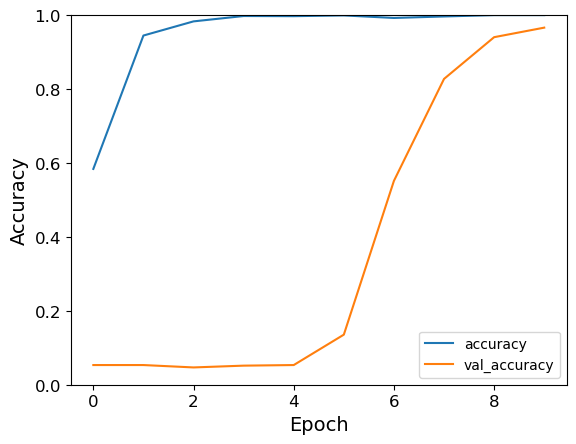

In [84]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
plt.show()

In [85]:
# Assuming 'model' is your compiled Keras model and 'x_test', 'y_test' are your test data

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

20/20 - 0s - 12ms/step - accuracy: 0.9661 - loss: 0.1132
Test Accuracy: 96.61%


In [97]:
# -------------------------------- MODEL ANDREW BERG --------------------------------------------
# Resource: https://pyimagesearch.com/2018/12/31/keras-conv2d-and-convolutional-layers/
# ---------------------------------------------------------------------------------------------
# Create convolutional base
import keras
from keras import layers
from keras.layers import Activation

model = keras.Sequential()
model.add(keras.Input(shape=(128, 128, 3)))
# resphapeto 24x24 image with 1 color channel, greyscale
# model. add(layers.Reshape((24, 24, 1)))

model.add(layers.Conv2D(16, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(Activation('relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.BatchNormalization())

# add dense layers on top
model.add(layers.Flatten())

# add dropout layer to prevent overfitting
model.add(layers.Dropout(0.5))
model.add(layers.Dense(256, activation='relu'))

# avoid dropout layer before last dense layer
model.add(layers.Dense(32))

model.summary()

# consider adding padding = 'same'

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,226,816 (16.12 MB)

 Trainable params: 4,226,592 (16.12 MB)

 Non-trainable params: 224 (896.00 B)

In [101]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))

Epoch 1/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5423 - loss: 7.8723 - val_accuracy: 0.1823 - val_loss: 120.6922
Epoch 2/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7798 - loss: 0.8708 - val_accuracy: 0.3290 - val_loss: 15.9826
Epoch 3/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8302 - loss: 0.6128 - val_accuracy: 0.7629 - val_loss: 1.9224
Epoch 4/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8694 - loss: 0.4860 - val_accuracy: 0.8097 - val_loss: 0.8705
Epoch 5/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.8815 - loss: 0.4768 - val_accuracy: 0.7952 - val_loss: 0.8124
Epoch 6/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8710 - loss: 0.6301 - val_accuracy: 0.5565 - val_loss: 6.7669
Epoch 7/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8669 - loss: 0.5727 - val_accuracy: 0.8145 - val_loss: 1.2903
Epoch 8/10
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8806 - loss: 0.5176 - val_accuracy: 0.6581 

20/20 - 0s - 12ms/step - accuracy: 0.7403 - loss: 2.0882


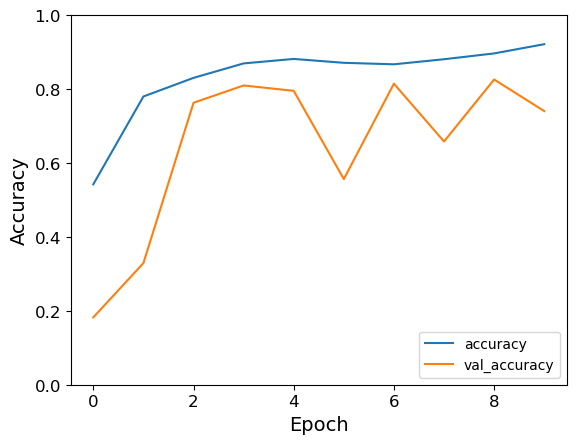

In [102]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)
plt.show()

In [103]:
# Assuming 'model' is your compiled Keras model and 'x_test', 'y_test' are your test data

# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

20/20 - 0s - 12ms/step - accuracy: 0.7403 - loss: 2.0882
Test Accuracy: 74.03%
